In [1]:
import pandas as pd
import numpy as n
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('/Users/songtaesung/Desktop/projects/product-qa-rag/data/raw_reviews.csv')
df.head()

,rating,title,text,images,asin,parent_asin,user_id,timestamp,helpful_vote,verified_purchase
0,3.0,Smells like gasoline! Going back!,First & most offensive: they reek of gasoline ...,[{'small_image_url': 'https://m.media-amazon.c...,B083NRGZMM,B083NRGZMM,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,1658185117948,0,True
1,1.0,Didn’t work at all lenses loose/broken.,These didn’t work. Idk if they were damaged in...,[],B07N69T6TM,B07N69T6TM,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,1592678549731,0,True
2,5.0,Excellent!,I love these. They even come with a carry case...,[],B01G8JO5F2,B01G8JO5F2,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,1523093017534,0,True
3,5.0,Great laptop backpack!,I was searching for a sturdy backpack for scho...,[],B001OC5JKY,B001OC5JKY,AGGZ357AO26RQZVRLGU4D4N52DZQ,1290278495000,18,True
4,5.0,Best Headphones in the Fifties price range!,I've bought these headphones three times becau...,[],B013J7WUGC,B07CJYMRWM,AG2L7H23R5LLKDKLBEF2Q3L2MVDA,1676601581238,0,True


In [3]:
print(df.shape)

(2000, 10)


In [4]:
df.columns.tolist()

['rating',
 'title',
 'text',
 'images',
 'asin',
 'parent_asin',
 'user_id',
 'timestamp',
 'helpful_vote',
 'verified_purchase']

In [5]:
df.dtypes

rating               float64
title                    str
text                     str
images                   str
asin                     str
parent_asin              str
user_id                  str
timestamp              int64
helpful_vote           int64
verified_purchase       bool
dtype: object

In [6]:
df.isnull().sum()

rating               0
title                0
text                 0
images               0
asin                 0
parent_asin          0
user_id              0
timestamp            0
helpful_vote         0
verified_purchase    0
dtype: int64

In [7]:
df["word_count"] = df["text"].astype(str).apply(lambda x: len(x.split()))
df["word_count"].describe()

count    2000.000000
mean       64.045500
std        86.832375
min         0.000000
25%        14.000000
50%        36.000000
75%        79.000000
max      1060.000000
Name: word_count, dtype: float64

<Axes: >

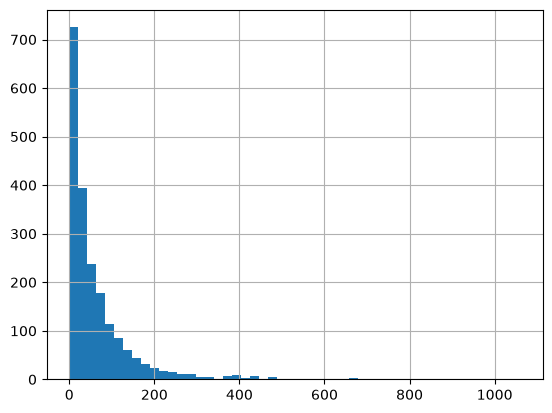

In [8]:
df["word_count"].hist(bins=50)

In [9]:
df.sort_values("word_count", ascending=False)[["text", "word_count"]].head(5)

,text,word_count
1204,I received a Kindle 2 as a gift recently. I'd ...,1060
556,I am going to provide a list of pros and cons....,826
1122,I just started using my camera yesterday and m...,682
1110,This is a very expensive KVM switch that is re...,669
1100,Maybe it is just because I haven't upgraded my...,662


In [10]:
empty_count = (df["word_count"] == 0).sum()
print(f"Empty reviews: {empty_count} out of {len(df)}")

Empty reviews: 1 out of 2000


In [11]:
(df["word_count"] > 150).sum()

np.int64(201)

In [12]:
import sys
sys.path.append("../src")

from ingest import split_into_sentences

long_review = df[df["word_count"] > 150].iloc[0]["text"]
sentences = split_into_sentences(long_review)
print(len(sentences), "sentences")
for s in sentences[:5]:
    print("-", s)

16 sentences
- First & most offensive: they reek of gasoline so if you are sensitive/allergic to petroleum products like I am you will want to pass on these.
- Second: the phone adapter is useless as-is.
- Mine was not drilled far enough to be able to tighten it into place for my iPhone 12 max.
- It just slipped & slid all over.
- Stupid me putting the adapter together first without picking up the binoculars to smell them bc I wasted 15 minutes trying to figure out how to put the adapter together bc it does not come with instructions!


In [13]:
import sys
sys.path.append("src")
from vector_store import VectorStore
from embed_index import client, EMBED_MODEL_NAME

store = VectorStore.load("data/vector_store.json")
query_emb = client.feature_extraction("good battery life", model=EMBED_MODEL_NAME).tolist()
results = store.query(query_emb, n_results=3)
print(results["documents"])

/Users/songtaesung/Desktop/projects/product-qa-rag/venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


FileNotFoundError: [Errno 2] No such file or directory: 'data/vector_store.json'